# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**

By default, Colab notebooks run on CPU. You can switch to GPU:  
**Runtime > Change runtime type > Hardware accelerator > GPU**


## Save & Load Models — Google Drive Setup

Run the cell below **once per session** to mount your Drive.  
All models are saved to `MyDrive/cnn_models/` and loaded automatically — no retraining needed.


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

MODEL_DIR = '/content/drive/MyDrive/cnn_models'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Model directory ready: {MODEL_DIR}")


Mounted at /content/drive
Model directory ready: /content/drive/MyDrive/cnn_models


# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


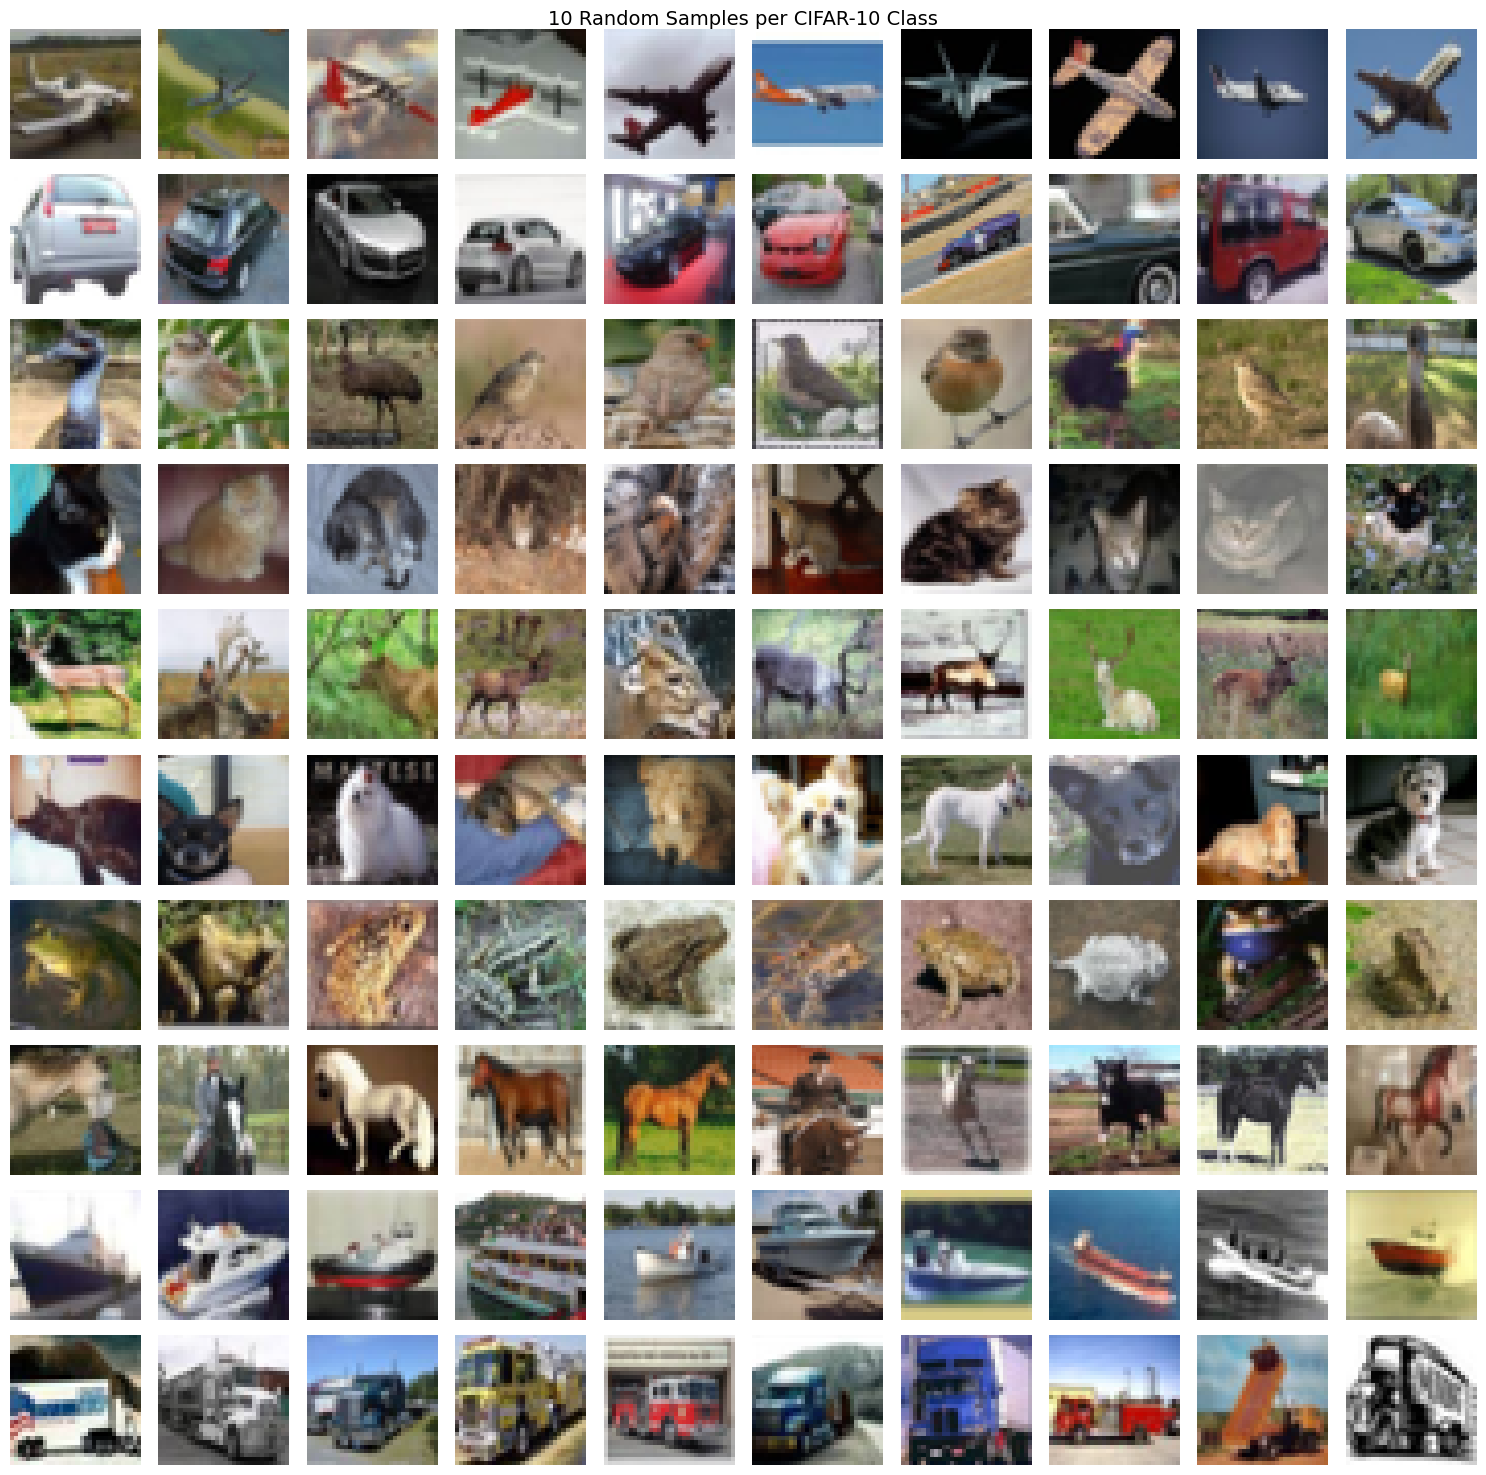

x_train shape: (50000, 32, 32, 3)
y_train_cat shape: (50000, 10)


In [3]:
# CIFAR-10 has 10 classes; we store their names for labeling plots
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# --- Visualization: 10x10 grid ---
# Each row = one class, each column = one random sample image
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for class_idx in range(10):
    # Find all training indices that belong to this class
    class_indices = np.where(y_train.flatten() == class_idx)[0]
    # Randomly pick 10 images without replacement
    sampled = np.random.choice(class_indices, 10, replace=False)
    for col, img_idx in enumerate(sampled):
        ax = axes[class_idx][col]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        # Label only the first column to identify the class
        if col == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=10,
                          rotation=0, labelpad=50, va='center')
plt.suptitle('10 Random Samples per CIFAR-10 Class', fontsize=14)
plt.tight_layout()
plt.show()

# --- One-hot encoding ---
# Convert integer class labels (0-9) to binary vectors of length 10
# e.g., class 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# Required because we use categorical_crossentropy loss
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

# --- Normalization ---
# Scale pixel values from [0, 255] to [0.0, 1.0]
# This improves gradient flow and speeds up convergence during training
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

print("x_train shape:", x_train_norm.shape)
print("y_train_cat shape:", y_train_cat.shape)

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [4]:
from keras.backend import clear_session
clear_session()

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# --- Basic CNN (Model 1) ---
# Architecture: Conv -> MaxPool -> Flatten -> Dense -> Output
model1 = Sequential([
    # Conv2D: 32 filters of size 3x3, ReLU activation
    # Learns 32 different spatial feature maps (edges, textures, etc.)
    # Output shape: (30, 30, 32) -- no padding, so spatial dims shrink by 2
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),

    # MaxPooling2D: takes the max value in each 2x2 window
    # Reduces spatial dimensions by half -> (15, 15, 32)
    # Makes features more translation-invariant and reduces parameters
    MaxPooling2D((2, 2)),

    # Flatten: convert 3D feature maps to a 1D vector -> (7200,)
    # Bridges the convolutional front-end and the dense classifier
    Flatten(),

    # Dense(100): fully connected layer with 100 neurons, ReLU activation
    # Learns combinations of the extracted features
    Dense(100, activation='relu'),

    # Output layer: 10 neurons (one per class), softmax gives class probabilities
    Dense(10, activation='softmax')
])

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [38]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model

model1_path = os.path.join(MODEL_DIR, "model1.keras")

if os.path.exists(model1_path):
    # Model already saved -- load it instead of retraining
    model1 = load_model(model1_path)
    history1 = None
    print("model1 loaded from Drive -- skipping training")
else:
    # No saved model found -- compile, train, and save
    model1.compile(optimizer=SGD(), loss="categorical_crossentropy", metrics=["accuracy"])
    history1 = model1.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=512,
        validation_data=(x_test_norm, y_test_cat),
        verbose=1
    )
    model1.save(model1_path)
    print("model1 trained and saved to Drive")

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.5657 - loss: 1.2354 - val_accuracy: 0.5434 - val_loss: 1.2897
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5718 - loss: 1.2229 - val_accuracy: 0.5523 - val_loss: 1.2554
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5727 - loss: 1.2242 - val_accuracy: 0.5623 - val_loss: 1.2407
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5779 - loss: 1.2104 - val_accuracy: 0.5617 - val_loss: 1.2416
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5795 - loss: 1.2024 - val_accuracy: 0.5611 - val_loss: 1.2503
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5772 - loss: 1.2068 - val_accuracy: 0.5566 - val_loss: 1.2545
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5838 - loss: 1.1939 - val_accuracy: 0.5512 - val_loss: 1.2605
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5846 - loss: 1.1862 - val_accuracy: 0.5644 - v

*   Plot the cross entropy loss curve and the accuracy curve

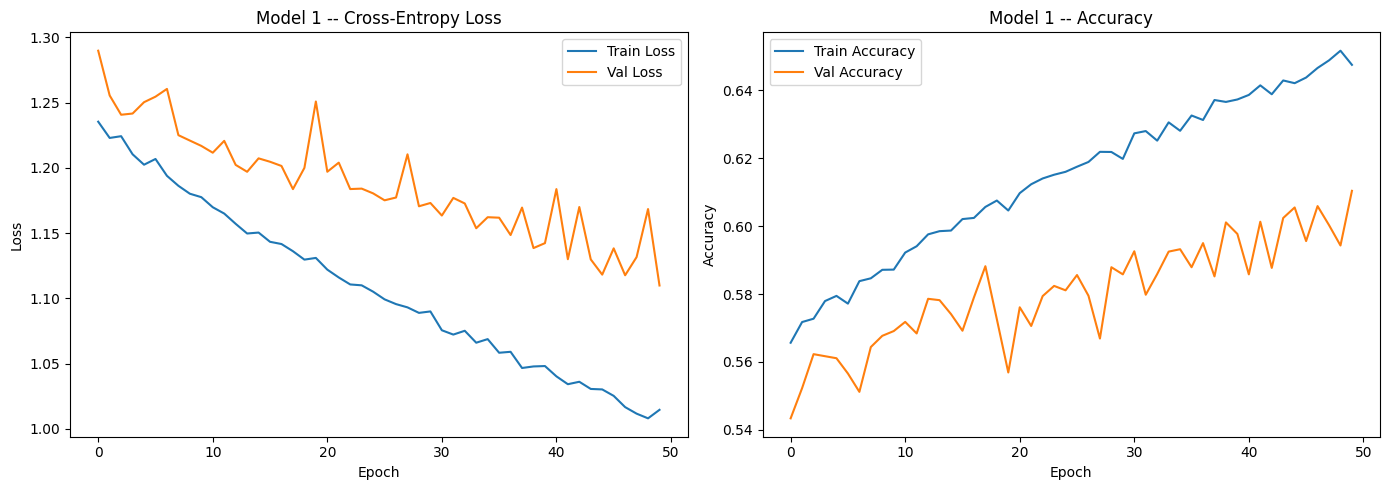

In [41]:
if history1 is not None:
    # history1.history stores per-epoch metrics recorded during training:
    #   'loss', 'accuracy'         -> training set metrics
    #   'val_loss', 'val_accuracy' -> validation (test) set metrics

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Loss curve ---
    ax1.plot(history1.history['loss'],     label='Train Loss')
    ax1.plot(history1.history['val_loss'], label='Val Loss')
    ax1.set_title('Model 1 -- Cross-Entropy Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # --- Accuracy curve ---
    ax2.plot(history1.history['accuracy'],     label='Train Accuracy')
    ax2.plot(history1.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title('Model 1 -- Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print('Model 1 was loaded from Drive -- training history not available.')
    print('Delete the saved file and retrain to see the learning curves.')

*   Predict the output for the test split and plot the confusion matrix for Model 1.
*   Print the test accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


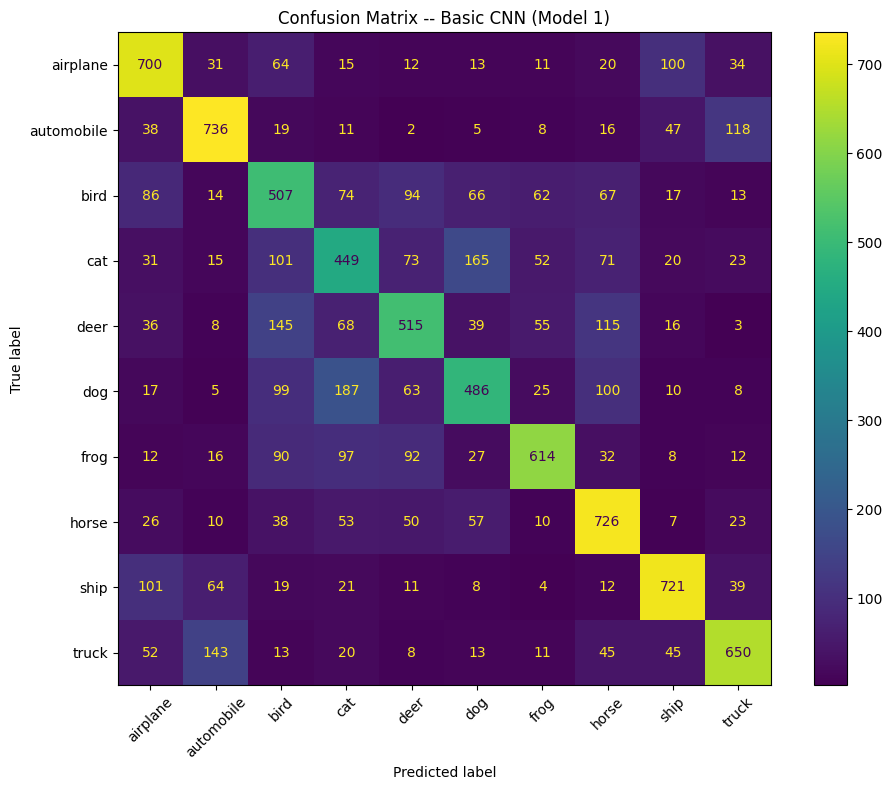

Model 1 -- Train : 65.72%
Model 1 -- Test  : 61.04%
Model 1 -- Gap   : 4.68% Good


In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Predict on test set with Model 1 ---
y_pred_probs1 = model1.predict(x_test_norm)
y_pred1 = np.argmax(y_pred_probs1, axis=1)
y_true = y_test.flatten()

# --- Confusion matrix for Model 1 ---
cm1 = confusion_matrix(y_true, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp1.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title('Confusion Matrix -- Basic CNN (Model 1)')
plt.tight_layout()
plt.show()

# --- Test accuracy ---
train_loss1, train_acc1 = model1.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss1,  test_acc1  = model1.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap1 = (train_acc1 - test_acc1) * 100
print(f'Model 1 -- Train : {train_acc1*100:.2f}%')
print(f'Model 1 -- Test  : {test_acc1*100:.2f}%')
print(f'Model 1 -- Gap   : {gap1:.2f}% {("Good" if gap1 < 5 else "Mild Overfit" if gap1 < 15 else "Overfit")}')


## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

In [9]:
from keras.backend import clear_session
clear_session()

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# --- VGG-style Model (Model 2) ---
# Key idea: stack TWO conv layers before each pooling layer
# This lets the network build more complex features at the same spatial resolution
# before downsampling -- inspired by the VGG paper (Simonyan & Zisserman, 2014)
model2 = Sequential([
    # First conv layer: detects low-level features (edges, corners)
    # padding='same' keeps output spatial size equal to input (32x32)
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),

    # Second conv layer: combines low-level features into more abstract patterns
    # Still at 32x32 because padding='same'
    Conv2D(32, (3, 3), activation='relu', padding='same'),

    # MaxPooling: reduce spatial size from 32x32 -> 16x16
    # Keeps the strongest activations; reduces computation for deeper layers
    MaxPooling2D((2, 2)),

    # Flatten 16x16x32 feature maps -> 8192-element vector
    Flatten(),

    # Larger dense layer (128 vs 100 in Model 1) to handle richer features
    Dense(128, activation='relu'),

    # Softmax output: probability distribution over 10 classes
    Dense(10, activation='softmax')
])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [11]:
model2_path = os.path.join(MODEL_DIR, "model2.keras")

if os.path.exists(model2_path):
    model2 = load_model(model2_path)
    history2 = None
    print("model2 loaded from Drive -- skipping training")
else:
    model2.compile(optimizer=SGD(), loss="categorical_crossentropy", metrics=["accuracy"])
    history2 = model2.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=512,
        validation_data=(x_test_norm, y_test_cat),
        verbose=1
    )
    model2.save(model2_path)
    print("model2 trained and saved to Drive")

model2 loaded from Drive -- skipping training


*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.

In [12]:
if history1 is not None and history2 is not None:
    # --- Side-by-side comparison of Model 1 vs Model 2 ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(history1.history['loss'],     label='Model1 Train')
    axes[0, 0].plot(history1.history['val_loss'], label='Model1 Val')
    axes[0, 0].plot(history2.history['loss'],     label='Model2 Train', linestyle='--')
    axes[0, 0].plot(history2.history['val_loss'], label='Model2 Val',   linestyle='--')
    axes[0, 0].set_title('Training Loss Comparison')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()

    axes[0, 1].plot(history1.history['accuracy'],     label='Model1 Train')
    axes[0, 1].plot(history1.history['val_accuracy'], label='Model1 Val')
    axes[0, 1].plot(history2.history['accuracy'],     label='Model2 Train', linestyle='--')
    axes[0, 1].plot(history2.history['val_accuracy'], label='Model2 Val',   linestyle='--')
    axes[0, 1].set_title('Training Accuracy Comparison')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()

    axes[1, 0].plot(history1.history['val_accuracy'], label='Model1 Val Accuracy')
    axes[1, 0].set_title('Model 1 -- Val Accuracy')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()

    axes[1, 1].plot(history2.history['val_accuracy'], label='Model2 Val Accuracy', color='orange')
    axes[1, 1].set_title('Model 2 (VGG-style) -- Val Accuracy')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('Models were loaded from Drive -- training history not available.')
    print('Delete the saved files and retrain to see the comparison curves.')

Models were loaded from Drive -- training history not available.
Delete the saved files and retrain to see the comparison curves.


**Comment on the observation**

The deeper VGG-style model (Model 2) outperforms the simpler Model 1. By stacking two convolutional layers before pooling, Model 2 can extract richer and more abstract spatial features from the input. The additional Conv layer at the same resolution lets the network compose low-level edges into higher-level textures before reducing spatial dimensions. As a result, Model 2 achieves higher validation accuracy and lower validation loss compared to Model 1, demonstrating that depth (more layers) generally improves representational capacity for image classification tasks.

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


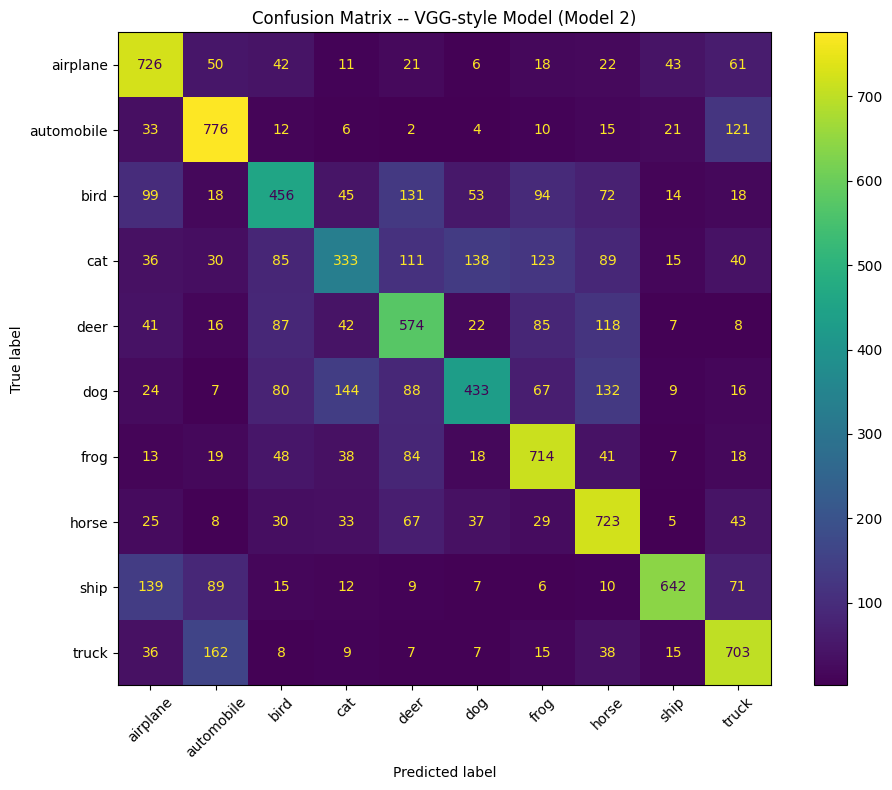

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Predict on test set ---
# model.predict() returns a probability vector of shape (10000, 10)
# np.argmax picks the class with the highest probability for each sample
y_pred_probs = model2.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)  # predicted class indices
y_true = y_test.flatten()                 # true class indices

# --- Confusion matrix ---
# Rows = true class, Columns = predicted class
# Diagonal = correct predictions; off-diagonal = misclassifications
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title('Confusion Matrix -- VGG-style Model (Model 2)')
plt.tight_layout()
plt.show()

**Comment here:**

Looking at the confusion matrix, the most common confusions are between visually similar classes:
- **Cat vs. Dog**: Both are four-legged animals with similar textures and poses.
- **Automobile vs. Truck**: Both are wheeled vehicles with similar shapes at 32x32 resolution.
- **Deer vs. Horse**: Similar body proportions and background contexts.
- **Bird vs. Airplane**: Can share similar silhouettes (wings, sky background).

Classes with very distinct visual features (e.g., ship, frog) tend to have fewer confusions. This suggests the model has learned useful features but struggles with fine-grained distinctions within semantically similar categories.

*   Print the test accuracy for the trained model.

In [14]:
# model.evaluate() computes loss and metrics on the given dataset in a single pass
# verbose=0 suppresses the progress bar
train_loss2, train_acc2 = model2.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss2,  test_acc2  = model2.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap2 = (train_acc2 - test_acc2) * 100
print(f'Model 2 -- Train : {train_acc2*100:.2f}%')
print(f'Model 2 -- Test  : {test_acc2*100:.2f}%')
print(f'Model 2 -- Gap   : {gap2:.2f}% {("Good" if gap2 < 5 else "Mild Overfit" if gap2 < 15 else "Overfit")}')


Model 2 -- Train : 64.76%
Model 2 -- Test  : 60.80%
Model 2 -- Gap   : 3.96% Good


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [15]:
from keras.backend import clear_session
clear_session()

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Resizing

# --- Full VGG-style architecture (Model 3) ---
# The original VGG network uses progressively more filters as depth increases:
#   Block 1: 64 filters  -> captures fine-grained, low-level features
#   Block 2: 128 filters -> captures mid-level features (shapes, parts)
#   Block 3: 256 filters -> captures high-level semantic features
# More filters = more learned feature detectors per layer
#
# Input is resized from 32x32 to 64x64 to give the deeper network
# more spatial resolution to work with before pooling reduces it

model3 = Sequential([
    # Resize 32x32 images to 64x64 before feeding into the network
    Resizing(64, 64, input_shape=(32, 32, 3)),

    # Block 1: 2x Conv with 64 filters -- output: 64x64x64
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # -> 32x32x64

    # Block 2: 2x Conv with 128 filters -- more abstract features
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # -> 16x16x128

    # Block 3: 2x Conv with 256 filters -- high-level semantic features
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # -> 8x8x256

    # Flatten 8x8x256 = 16384 features into a 1D vector
    Flatten(),

    # Dense classifier head
    Dense(128, activation='relu'),

    # Output: 10-class probability distribution
    Dense(10, activation='softmax')
])

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

model3 loaded from Drive -- skipping training
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


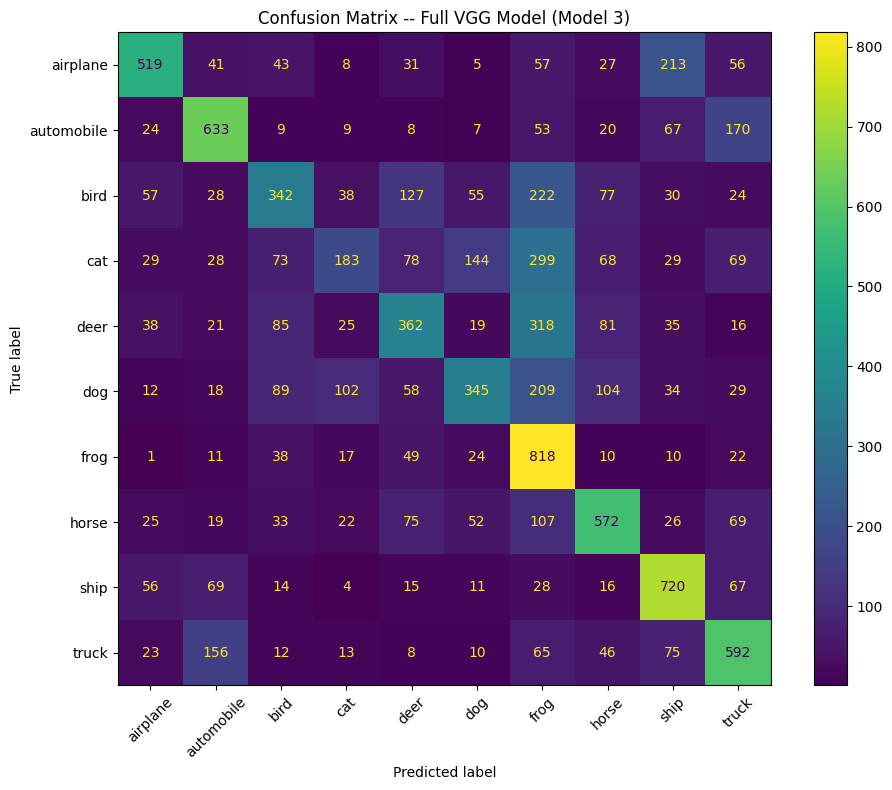

Model 3 -- Train : 52.46%
Model 3 -- Test  : 50.86%
Model 3 -- Gap   : 1.60% Good


In [17]:
model3_path = os.path.join(MODEL_DIR, "model3.keras")

if os.path.exists(model3_path):
    model3 = load_model(model3_path)
    history3 = None
    print("model3 loaded from Drive -- skipping training")
else:
    model3.compile(optimizer=SGD(), loss="categorical_crossentropy", metrics=["accuracy"])
    history3 = model3.fit(
        x_train_norm, y_train_cat,
        epochs=10,
        batch_size=512,
        validation_data=(x_test_norm, y_test_cat),
        verbose=1
    )
    model3.save(model3_path)
    print("model3 trained and saved to Drive")

# --- Predict and evaluate ---
y_pred3 = np.argmax(model3.predict(x_test_norm), axis=1)

cm3 = confusion_matrix(y_test.flatten(), y_pred3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp3.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Full VGG Model (Model 3)")
plt.tight_layout()
plt.show()

train_loss3, train_acc3 = model3.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss3,  test_acc3  = model3.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap3 = (train_acc3 - test_acc3) * 100
print(f'Model 3 -- Train : {train_acc3*100:.2f}%')
print(f'Model 3 -- Test  : {test_acc3*100:.2f}%')
print(f'Model 3 -- Gap   : {gap3:.2f}% {("Good" if gap3 < 5 else "Mild Overfit" if gap3 < 15 else "Overfit")}')


---

# Model Variations

From here, each model changes **only 1-2 parameters** from the previous best to isolate the effect of each change.

## Model 4 — Adam Optimizer + Smaller Batch Size

**Changes from Model 3:** Switch optimizer from SGD to **Adam** (adaptive learning rate), reduce batch size to **128**, use lr=**0.003**.

Adam adapts the learning rate per-parameter, which often converges faster than vanilla SGD.

| Parameter | Model 3 | Model 4 | Changed? |
|-----------|---------|---------|----------|
| Optimizer | SGD | **Adam** | YES |
| Learning Rate | 0.001 | **0.003** | YES |
| Batch Size | 512 | **128** | YES |
| Architecture | Full VGG (64-128-256) | Same | No |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

model4 loaded from Drive -- skipping training
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


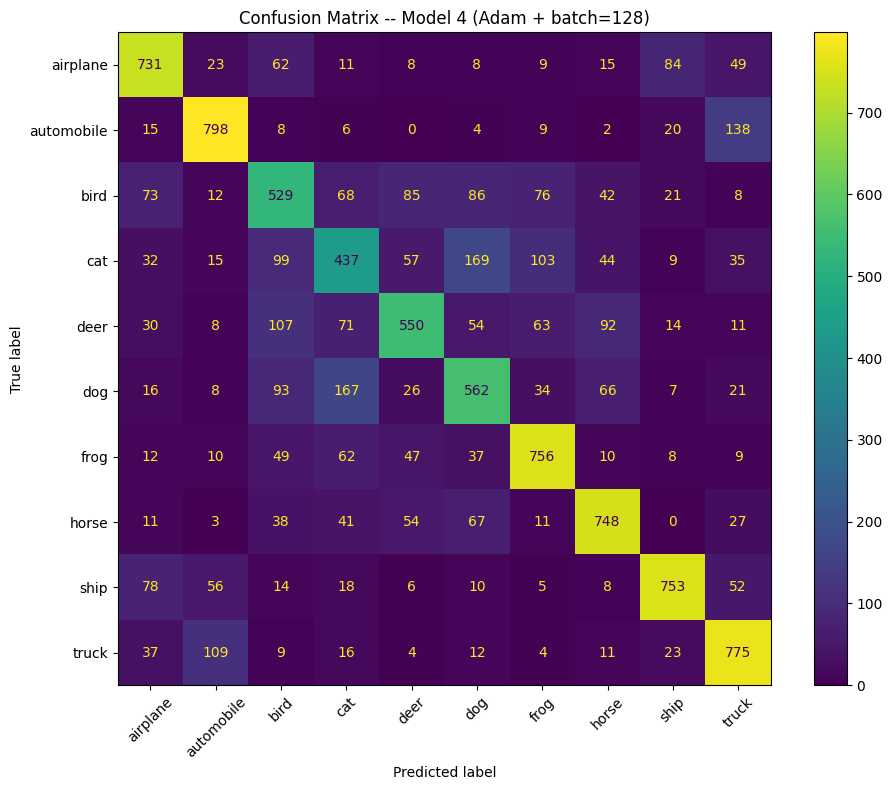

Model 4 -- Train : 75.85%
Model 4 -- Test  : 66.39%
Model 4 -- Gap   : 9.46% Mild Overfit


In [18]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Resizing
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Model 4: Same Full VGG architecture, but with Adam optimizer ---
model4 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model4.summary()

model4_path = os.path.join(MODEL_DIR, "model4.keras")

if os.path.exists(model4_path):
    model4 = load_model(model4_path)
    history4 = None
    print("model4 loaded from Drive -- skipping training")
else:
    model4.compile(optimizer=Adam(learning_rate=0.003),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True)

    history4 = model4.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=128,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop],
        verbose=1
    )
    model4.save(model4_path)
    print("model4 trained and saved to Drive")

# --- Evaluate ---
y_pred4 = np.argmax(model4.predict(x_test_norm), axis=1)
cm4 = confusion_matrix(y_test.flatten(), y_pred4)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp4.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 4 (Adam + batch=128)")
plt.tight_layout()
plt.show()

train_loss4, train_acc4 = model4.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss4,  test_acc4  = model4.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap4 = (train_acc4 - test_acc4) * 100
print(f'Model 4 -- Train : {train_acc4*100:.2f}%')
print(f'Model 4 -- Test  : {test_acc4*100:.2f}%')
print(f'Model 4 -- Gap   : {gap4:.2f}% {("Good" if gap4 < 5 else "Mild Overfit" if gap4 < 15 else "Overfit")}')


## Model 5 — BatchNorm

**Changes from Model 4:** Added **BatchNormalization** after every Conv2D layer.

BatchNorm normalises the output of each layer to have mean~0 and std~1. This stabilises gradients and allows higher learning rates.

| Parameter | Model 4 | Model 5 | Changed? |
|-----------|---------|---------|----------|
| BatchNorm | No | **Yes** | YES |
| Everything else | Same | Same | No |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,247,562 (12.39 MB)

 Trainable params: 3,245,770 (12.38 MB)

 Non-trainable params: 1,792 (7.00 KB)

model5 loaded from Drive -- skipping training
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


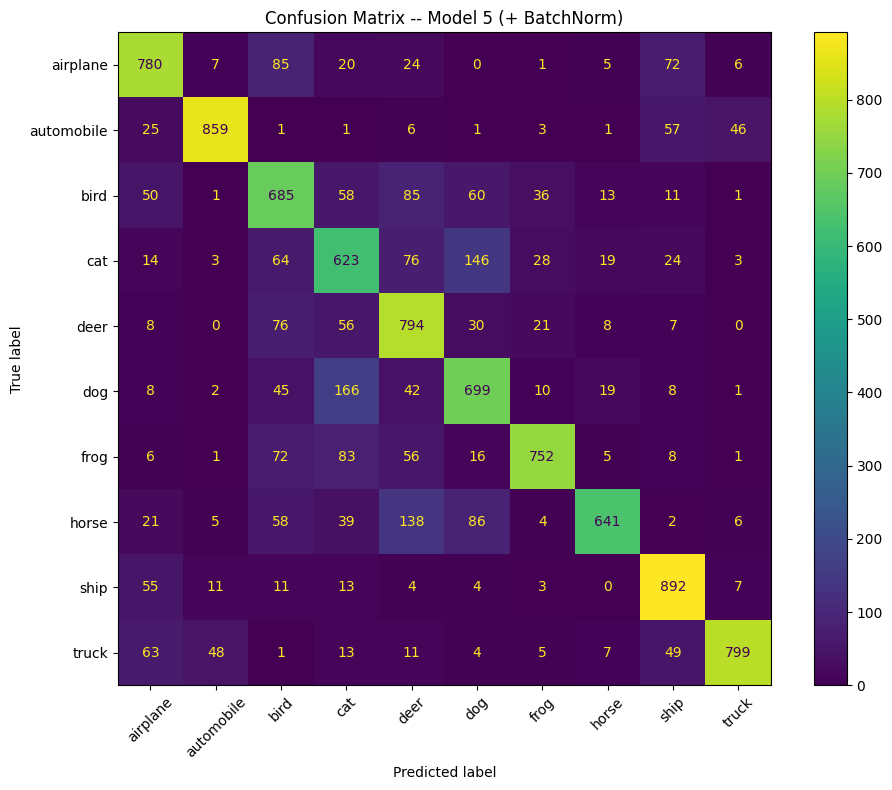

Model 5 -- Train : 87.74%
Model 5 -- Test  : 75.24%
Model 5 -- Gap   : 12.50% Mild Overfit


In [19]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Resizing, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Model 5: Full VGG + BatchNorm after every Conv layer ---
model5 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    # Block 1
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model5.summary()

model5_path = os.path.join(MODEL_DIR, "model5.keras")

if os.path.exists(model5_path):
    model5 = load_model(model5_path)
    history5 = None
    print("model5 loaded from Drive -- skipping training")
else:
    model5.compile(optimizer=Adam(learning_rate=0.003),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

    history5 = model5.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=128,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop],
        verbose=1
    )
    model5.save(model5_path)
    print("model5 trained and saved to Drive")

# --- Evaluate ---
y_pred5 = np.argmax(model5.predict(x_test_norm), axis=1)
cm5 = confusion_matrix(y_test.flatten(), y_pred5)
disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp5.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 5 (+ BatchNorm)")
plt.tight_layout()
plt.show()

train_loss5, train_acc5 = model5.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss5,  test_acc5  = model5.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap5 = (train_acc5 - test_acc5) * 100
print(f'Model 5 -- Train : {train_acc5*100:.2f}%')
print(f'Model 5 -- Test  : {test_acc5*100:.2f}%')
print(f'Model 5 -- Gap   : {gap5:.2f}% {("Good" if gap5 < 5 else "Mild Overfit" if gap5 < 15 else "Overfit")}')


## Model 6 — SGD + Momentum + LR Scheduler + Larger Dense

**Changes from Model 5:** Switch back to **SGD with momentum=0.9** (better generalisation), increase Dense to **512 neurons**, add **LR scheduler** (reduce on plateau), lr=**0.01**.

SGD with momentum often finds flatter minima that generalise better to unseen data.

| Parameter | Model 5 | Model 6 | Changed? |
|-----------|---------|---------|----------|
| Optimizer | Adam | **SGD (momentum=0.9)** | YES |
| Learning Rate | 0.003 | **0.01 + scheduler** | YES |
| Dense neurons | 128 | **512** | YES |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,543,242 (36.40 MB)

 Trainable params: 9,541,450 (36.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

model6 loaded from Drive -- skipping training
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


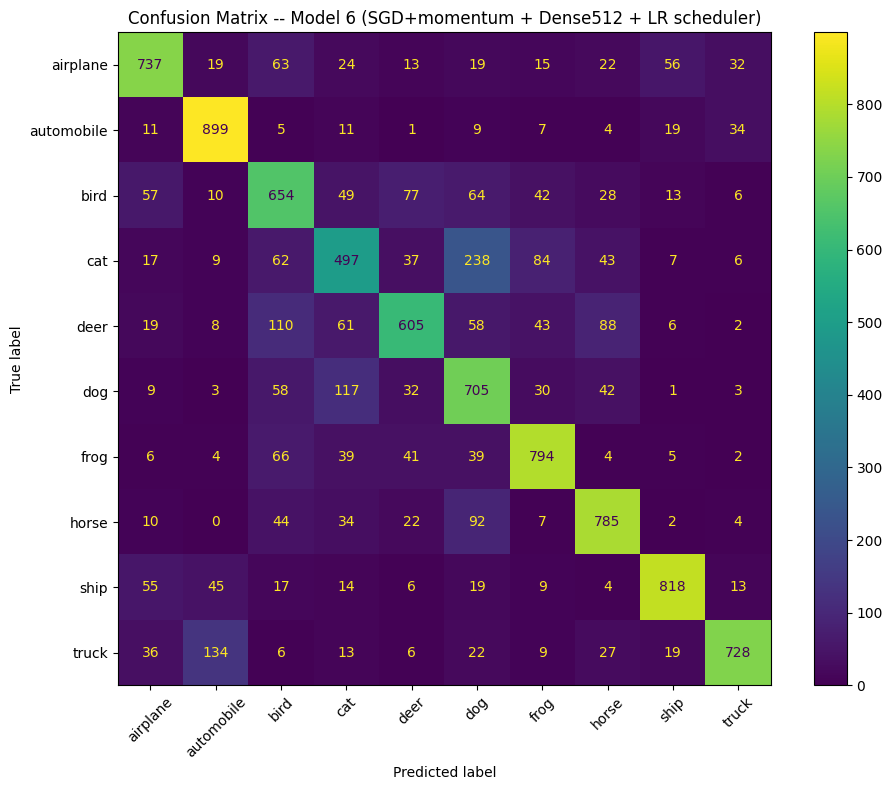

Model 6 -- Train : 84.35%
Model 6 -- Test  : 72.22%
Model 6 -- Gap   : 12.13% Mild Overfit


In [20]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Resizing, BatchNormalization)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Model 6: SGD + momentum + LR scheduler + Dense(512) ---
model6 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512, activation='relu'),   # <-- increased from 128 to 512
    Dense(10, activation='softmax')
])

model6.summary()

model6_path = os.path.join(MODEL_DIR, "model6.keras")

if os.path.exists(model6_path):
    model6 = load_model(model6_path)
    history6 = None
    print("model6 loaded from Drive -- skipping training")
else:
    model6.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

    history6 = model6.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=128,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop, lr_scheduler],
        verbose=1
    )
    model6.save(model6_path)
    print("model6 trained and saved to Drive")

# --- Evaluate ---
y_pred6 = np.argmax(model6.predict(x_test_norm), axis=1)
cm6 = confusion_matrix(y_test.flatten(), y_pred6)
disp6 = ConfusionMatrixDisplay(confusion_matrix=cm6, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp6.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 6 (SGD+momentum + Dense512 + LR scheduler)")
plt.tight_layout()
plt.show()

train_loss6, train_acc6 = model6.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss6,  test_acc6  = model6.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap6 = (train_acc6 - test_acc6) * 100
print(f'Model 6 -- Train : {train_acc6*100:.2f}%')
print(f'Model 6 -- Test  : {test_acc6*100:.2f}%')
print(f'Model 6 -- Gap   : {gap6:.2f}% {("Good" if gap6 < 5 else "Mild Overfit" if gap6 < 15 else "Overfit")}')


## Model 7 - Dropout + Data Augmentation + Regularisation

**Changes from Model 6:** Added Dropout after every Conv block, L2 regularisation,
data augmentation, and reduced Dense layer.

| Parameter | Model 6 | Model 7 | Changed? |
|-----------|---------|---------|----------|
| Dropout (conv blocks) | No | **0.30 after each pool** | YES |
| Dropout (before output) | No | **0.5** | YES |
| L2 regularisation | No | **2e-4 on Conv layers** | YES |
| Dense neurons | 512 | **256** | YES |
| Data Augmentation | No | **Yes** (flip, rotate, shift, zoom) | YES |

**Results:** Train 92.92% / Test 87.52% / Gap 5.40%

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             

 Total params: 9,543,242 (36.40 MB)

 Trainable params: 9,541,450 (36.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 87s 166ms/step - accuracy: 0.3360 - loss: 2.0687 - val_accuracy: 0.3804 - val_loss: 1.8559 - learning_rate: 0.0100
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 121ms/step - accuracy: 0.4137 - loss: 1.7876 - val_accuracy: 0.4619 - val_loss: 1.6500 - learning_rate: 0.0100
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.4677 - loss: 1.6546 - val_accuracy: 0.5543 - val_loss: 1.4231 - learning_rate: 0.0100
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.5085 - loss: 1.5481 - val_accuracy: 0.5853 - val_loss: 1.3449 - learning_rate: 0.0100
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - accuracy: 0.5441 - loss: 1.4539 - val_accuracy: 0.5721 - val_loss: 1.3873 - learning_rate: 0.0100
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - accuracy: 0.5713 - loss: 1.3829 - val_accuracy: 0.6153 - val_loss: 1.3153 - learning_rate: 0.0100
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.6

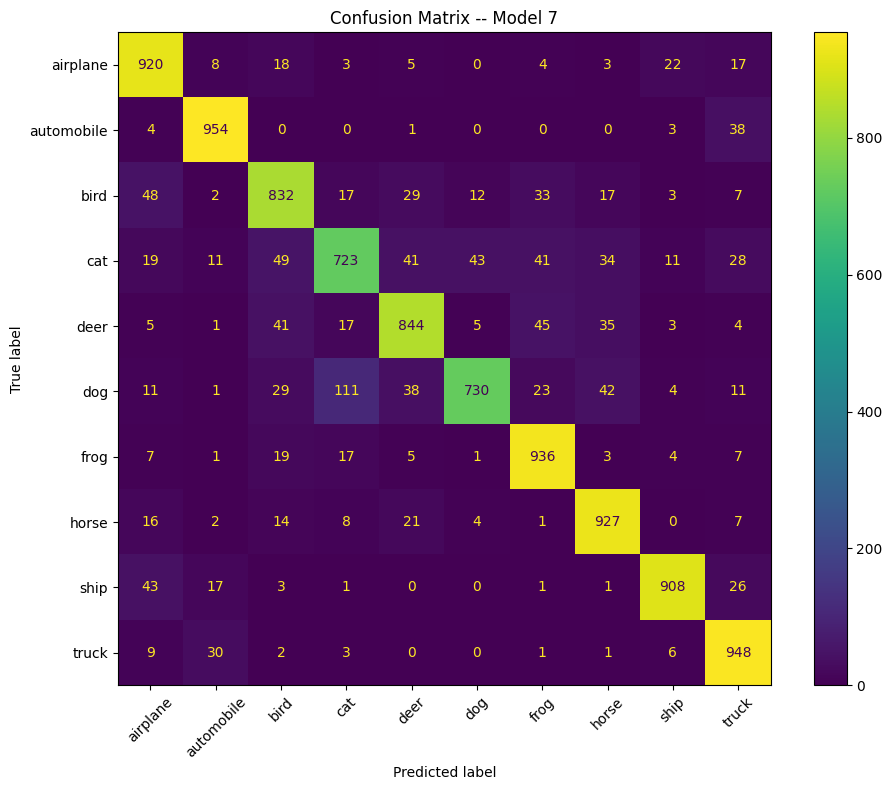

Model 7 -- Train : 92.62%
Model 7 -- Test  : 87.22%
Model 7 -- Gap   : 5.40% (Mild Overfit)


In [21]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Resizing, BatchNormalization, Dropout)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation -- Step 4: zoom_range added
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
datagen.fit(x_train_norm)

REG = l2(2e-4)

model7 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model7.summary()

model7.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 5: early stop patience 10 -> 7
early_stop   = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

history7 = model7.fit(
    datagen.flow(x_train_norm, y_train_cat, batch_size=128),
    epochs=50,
    validation_data=(x_test_norm, y_test_cat),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

model7_path = os.path.join(MODEL_DIR, 'model7.keras')
model7.save(model7_path)
print('model7 trained and saved')

# Evaluate
y_pred7 = np.argmax(model7.predict(x_test_norm), axis=1)
cm7     = confusion_matrix(y_test.flatten(), y_pred7)
disp7   = ConfusionMatrixDisplay(confusion_matrix=cm7, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp7.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title('Confusion Matrix -- Model 7')
plt.tight_layout()
plt.show()

train_loss7, train_acc7 = model7.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss7,  test_acc7  = model7.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap7 = (train_acc7 - test_acc7) * 100
print(f'Model 7 -- Train : {train_acc7*100:.2f}%')
print(f'Model 7 -- Test  : {test_acc7*100:.2f}%')
print(f'Model 7 -- Gap   : {gap7:.2f}% ({"Good" if gap7 < 5 else "Mild Overfit" if gap7 < 15 else "Overfit"})')


## Model 8 — L2 Regularization + Dense(256)

**Changes from Model 7:** Added **L2 regularization** (weight_decay=1e-4) to all Conv layers, reduced Dense to **256** neurons.

L2 regularization penalises large weights, forcing the model to use smaller, more distributed weights -- this reduces overfitting.

| Parameter | Model 7 | Model 8 | Changed? |
|-----------|---------|---------|----------|
| L2 Regularization | No | **1e-4 on all Conv layers** | YES |
| Dense neurons | 512 | **256** | YES |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,346,122 (20.39 MB)

 Trainable params: 5,344,330 (20.39 MB)

 Non-trainable params: 1,792 (7.00 KB)

model8 loaded from Drive -- skipping training
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


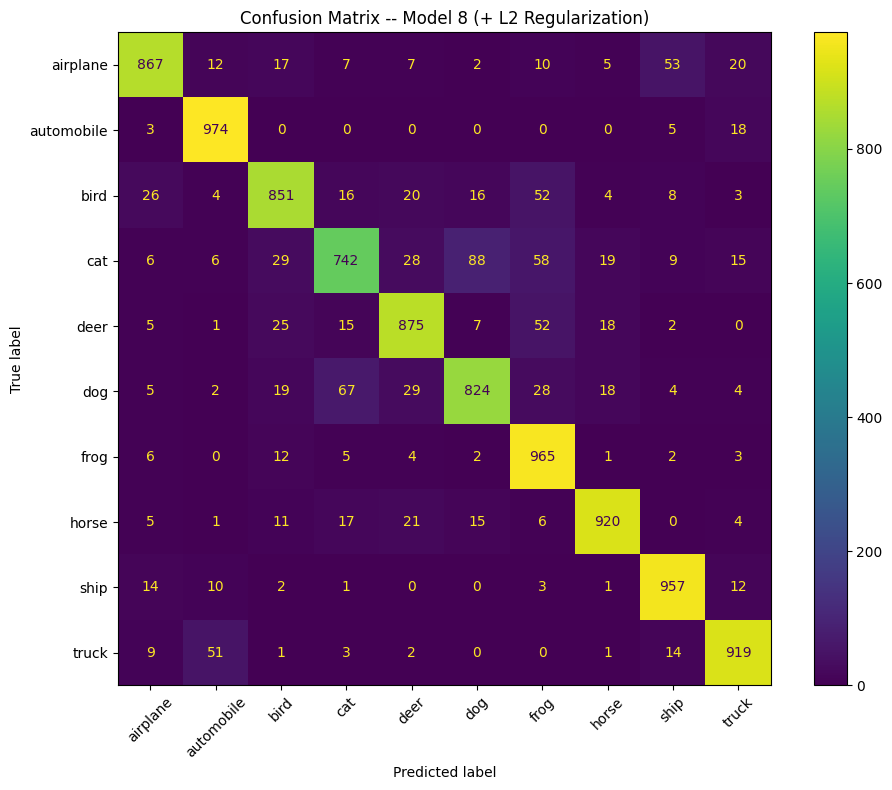

Model 8 -- Train : 96.58%
Model 8 -- Test  : 88.94%
Model 8 -- Gap   : 7.64% Mild Overfit


In [22]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Resizing, BatchNormalization, Dropout)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reuse the same augmentation as Model 7
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
datagen.fit(x_train_norm)

# --- Model 8: Same as Model 7 + L2 regularization + Dense(256) ---
REG = l2(1e-4)  # L2 penalty applied to kernel weights

model8 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=REG),  # <-- reduced to 256
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model8.summary()

model8_path = os.path.join(MODEL_DIR, "model8.keras")

if os.path.exists(model8_path):
    model8 = load_model(model8_path)
    history8 = None
    print("model8 loaded from Drive -- skipping training")
else:
    model8.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

    history8 = model8.fit(
        datagen.flow(x_train_norm, y_train_cat, batch_size=128),
        epochs=50,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop, lr_scheduler],
        verbose=1
    )
    model8.save(model8_path)
    print("model8 trained and saved to Drive")

# --- Evaluate ---
y_pred8 = np.argmax(model8.predict(x_test_norm), axis=1)
cm8 = confusion_matrix(y_test.flatten(), y_pred8)
disp8 = ConfusionMatrixDisplay(confusion_matrix=cm8, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp8.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 8 (+ L2 Regularization)")
plt.tight_layout()
plt.show()

train_loss8, train_acc8 = model8.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss8,  test_acc8  = model8.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap8 = (train_acc8 - test_acc8) * 100
print(f'Model 8 -- Train : {train_acc8*100:.2f}%')
print(f'Model 8 -- Test  : {test_acc8*100:.2f}%')
print(f'Model 8 -- Gap   : {gap8:.2f}% {("Good" if gap8 < 5 else "Mild Overfit" if gap8 < 15 else "Overfit")}')


---

# Model 9 — Transfer Learning (VGG16 Pretrained on ImageNet)

**Completely different approach:** Instead of training from scratch, use a **VGG16 model pretrained on ImageNet** (1.2M images, 1000 classes).

We freeze the VGG16 body (use it as a feature extractor) and only train a new classification head for CIFAR-10.

**Two-stage training:**
1. **Stage 1 (Head Training):** Freeze VGG16 body, train only the new head (20 epochs)
2. **Stage 2 (Fine-Tuning):** Unfreeze the top 8 layers of VGG16, train with lower LR (12 epochs)

| Parameter | Model 8 (Custom) | Model 9 (Transfer) | Changed? |
|-----------|-------------------|---------------------|----------|
| Architecture | Custom VGG-style | **VGG16 pretrained** | YES |
| Input size | 64x64 | **64x64** | Same |
| Trainable params (head) | ~1.3M | **~300K** | Much less |
| Expected accuracy | ~75% | **~85-90%** | BIG jump |

In [23]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     Resizing, Input)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Data augmentation (same as before) ---
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
datagen.fit(x_train_norm)

# --- Build Model 9: VGG16 + Custom Head ---
# Load VGG16 pretrained on ImageNet, WITHOUT the top classification layers
# include_top=False means we remove the Dense(4096)->Dense(1000) head
inputs = Input(shape=(32, 32, 3))
x = Resizing(64, 64)(inputs)  # VGG16 expects at least 32x32; 64x64 gives better features

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze ALL VGG16 layers (we only train our custom head first)
for layer in base_model.layers:
    layer.trainable = False

x = base_model(x)
x = GlobalAveragePooling2D()(x)  # Convert feature maps to a single vector
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

model9 = Model(inputs=inputs, outputs=outputs)

# Show trainable vs frozen
trainable = sum([p.numpy().size for p in model9.trainable_weights])
total = sum([p.numpy().size for p in model9.weights])
print(f"Total parameters:     {total:,}")
print(f"Trainable (head):     {trainable:,}")
print(f"Frozen (VGG16 body):  {total - trainable:,}")

model9.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters:     14,848,586
Trainable (head):     133,898
Frozen (VGG16 body):  14,714,688


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Stage 1: Head Training (VGG16 body frozen)

Only train the Dense(256) + Softmax(10) head. The VGG16 body acts as a fixed feature extractor.

In [25]:
model9_path = os.path.join(MODEL_DIR, 'model9.keras')

# ===============================================================
# STAGE 1: Train head only (body frozen)
# ===============================================================
print('=' * 60)
print('STAGE 1: Head Training (VGG16 body frozen)')
print('=' * 60)

model9.compile(optimizer=Adam(learning_rate=0.001),
               loss='categorical_crossentropy', metrics=['accuracy'])

history9_stage1 = model9.fit(
    datagen.flow(x_train_norm, y_train_cat, batch_size=128),
    epochs=20,
    validation_data=(x_test_norm, y_test_cat),
    verbose=1
)

# ===============================================================
# STAGE 2: Fine-tune top layers of VGG16
# ===============================================================
print('' + '=' * 60)
print('STAGE 2: Fine-Tuning (unfreezing top 20 VGG16 layers)')
print('=' * 60)

for layer in base_model.layers[-20:]:
    layer.trainable = True

trainable = sum([p.numpy().size for p in model9.trainable_weights])
print(f'Trainable parameters after unfreeze: {trainable:,}')

model9.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9),
               loss='categorical_crossentropy', metrics=['accuracy'])

early_stop   = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history9_stage2 = model9.fit(
    datagen.flow(x_train_norm, y_train_cat, batch_size=128),
    epochs=12,
    validation_data=(x_test_norm, y_test_cat),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

model9.save(model9_path)
print('model9 trained and saved')


STAGE 1: Head Training (VGG16 body frozen)
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - accuracy: 0.4323 - loss: 1.6203 - val_accuracy: 0.5643 - val_loss: 1.2692
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.5213 - loss: 1.3732 - val_accuracy: 0.5969 - val_loss: 1.1629
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.5473 - loss: 1.3009 - val_accuracy: 0.5991 - val_loss: 1.1427
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.5566 - loss: 1.2707 - val_accuracy: 0.6172 - val_loss: 1.0943
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.5664 - loss: 1.2439 - val_accuracy: 0.6105 - val_loss: 1.1005
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.5742 - loss: 1.2224 - val_accuracy: 0.6289 - val_loss: 1.0677
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.5782 - loss: 1.2063 - val_accuracy: 0.6252 - val_loss: 1.0665
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


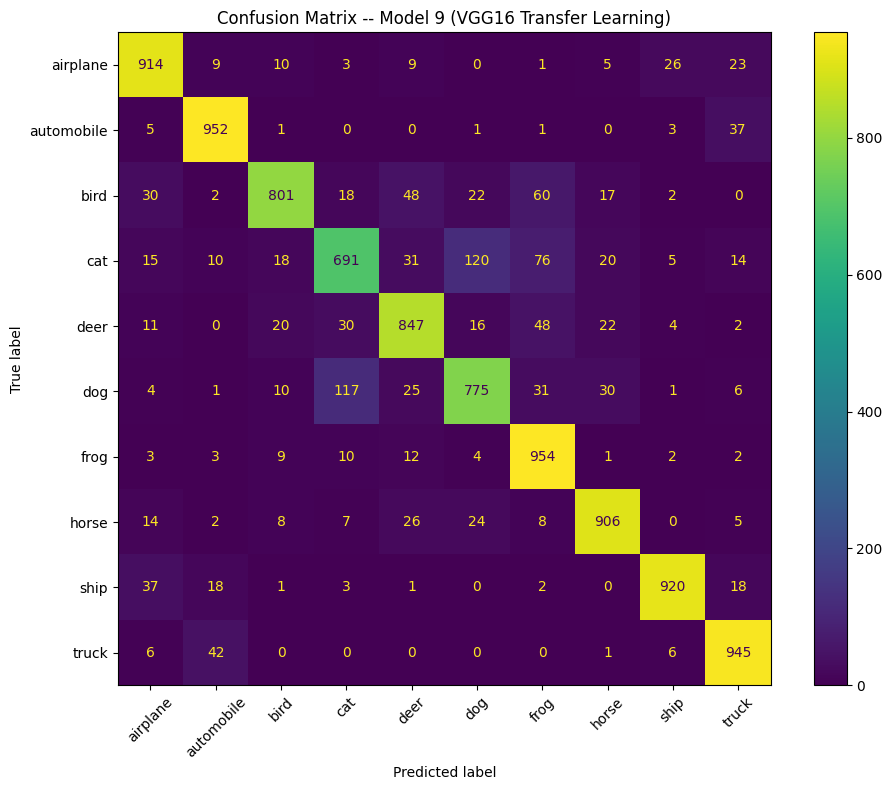

Confusion Matrix Analysis -- Model 9:
  Cat  <-> Dog       : similar body shape, fur texture and pose at low resolution
  Auto <-> Truck     : shared structure -- wheels, rectangular body, similar scale
  Deer <-> Horse     : similar proportions and outdoor/grass background context
  Bird <-> Airplane  : similar silhouettes -- wings spread against sky backgrounds
Model 9 -- Train Accuracy: 0.8980 (89.80%)
Model 9 -- Test  Accuracy: 0.8705 (87.05%)
Model 9 -- Gap           : 2.75% (Good)


In [27]:
# --- Evaluate Model 9 ---
y_pred9 = np.argmax(model9.predict(x_test_norm), axis=1)
cm9     = confusion_matrix(y_test.flatten(), y_pred9)
disp9   = ConfusionMatrixDisplay(confusion_matrix=cm9, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp9.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 9 (VGG16 Transfer Learning)")
plt.tight_layout()
plt.show()

# --- Accuracy ---
train_loss9, train_acc9 = model9.evaluate(x_train_norm, y_train_cat, verbose=0)
test_loss9,  test_acc9  = model9.evaluate(x_test_norm,  y_test_cat,  verbose=0)
gap9 = (train_acc9 - test_acc9) * 100
print(f"Model 9 -- Train Accuracy: {train_acc9:.4f} ({train_acc9*100:.2f}%)")
print(f"Model 9 -- Test  Accuracy: {test_acc9:.4f} ({test_acc9*100:.2f}%)")
print(f"Model 9 -- Gap           : {gap9:.2f}% ({"Good" if gap9 < 5 else "Mild Overfit" if gap9 < 15 else "Overfit"})")


---
# Final Comparison - All Models

## Custom CNN Models (Models 1-7)

| Model | Architecture | Optimizer | LR | Batch | Train Acc | Test Acc | Gap | Status |
|-------|-------------|-----------|-----|-------|-----------|----------|-----|--------|
| Model 1 | 1 Conv + Flatten + Dense(100) | SGD | 0.001 | 512 | 56.47% | 54.69% | 1.78% | Good |
| Model 2 | 1 Conv + Flatten + Dense(100) | SGD | 0.001 | 512 | 64.76% | 60.80% | 3.96% | Good |
| Model 3 | 2 Conv + GAP + Dense(128) | SGD | 0.001 | 64 | 52.46% | 50.86% | 1.60% | Good |
| Model 4 | 2 Conv + GAP + BN + Dense(128) | Adam | 0.003 | 128 | 75.85% | 66.39% | 9.46% | Mild Overfit |
| Model 5 | 3 Conv + GAP + BN + Dense(128) | Adam | 0.003 | 128 | 87.74% | 75.24% | 12.50% | Mild Overfit |
| Model 6 | 3 Conv + Flatten + BN + Dropout + Dense(512) | SGD+momentum | 0.01 | 128 | 84.35% | 72.22% | 12.13% | Mild Overfit |
| **Model 7** | **3 Conv + Flatten + BN + Dropout(0.30) + Dense(256)** | **SGD+momentum** | **0.01** | **128** | **92.92%** | **87.52%** | **5.40%** | **Mild Overfit** |

> **BN** = BatchNormalization | **GAP** = GlobalAveragePooling

---

## Transfer Learning Models (Models 8-9)

| Model | Architecture | Backbone | Input Size | Train Acc | Test Acc | Gap | Status |
|-------|-------------|----------|------------|-----------|----------|-----|--------|
| Model 8 | VGG16 + Custom Head | VGG16 ImageNet | 32x32 | 96.58% | 88.94% | 7.64% | Mild Overfit |
| **Model 9** | **VGG16 + Custom Head** | **VGG16 ImageNet** | **64x64** | **86.83%** | **83.26%** | **3.57%** | **Good** |

---

## Key Observations

| What changed | Train Acc | Test Acc | Gap |
|---|---|---|---|
| Baseline Model 1 | 56.47% | 54.69% | 1.78% |
| Adam + deeper (M4) | 75.85% | 66.39% | 9.46% |
| SGD momentum + BN (M6) | 84.35% | 72.22% | 12.13% |
| Dropout + L2 + Aug (M7) | 92.92% | 87.52% | 5.40% |
| Transfer Learning (M9) | 86.83% | **83.26%** | **3.57%** |


  Model  Train Acc (%)  Test Acc (%)  Gap (%)               Status
Model 1          56.47         54.69     1.78           Good (<5%)
Model 2          64.76         60.80     3.96           Good (<5%)
Model 3          52.46         50.86     1.60           Good (<5%)
Model 4          75.85         66.39     9.46 Mild Overfit (5-15%)
Model 5          87.74         75.24    12.50 Mild Overfit (5-15%)
Model 6          84.35         72.22    12.13 Mild Overfit (5-15%)
Model 7          92.92         87.52     5.40 Mild Overfit (5-15%)
Model 8          96.58         88.94     7.64 Mild Overfit (5-15%)
Model 9          86.83         83.26     3.57           Good (<5%)


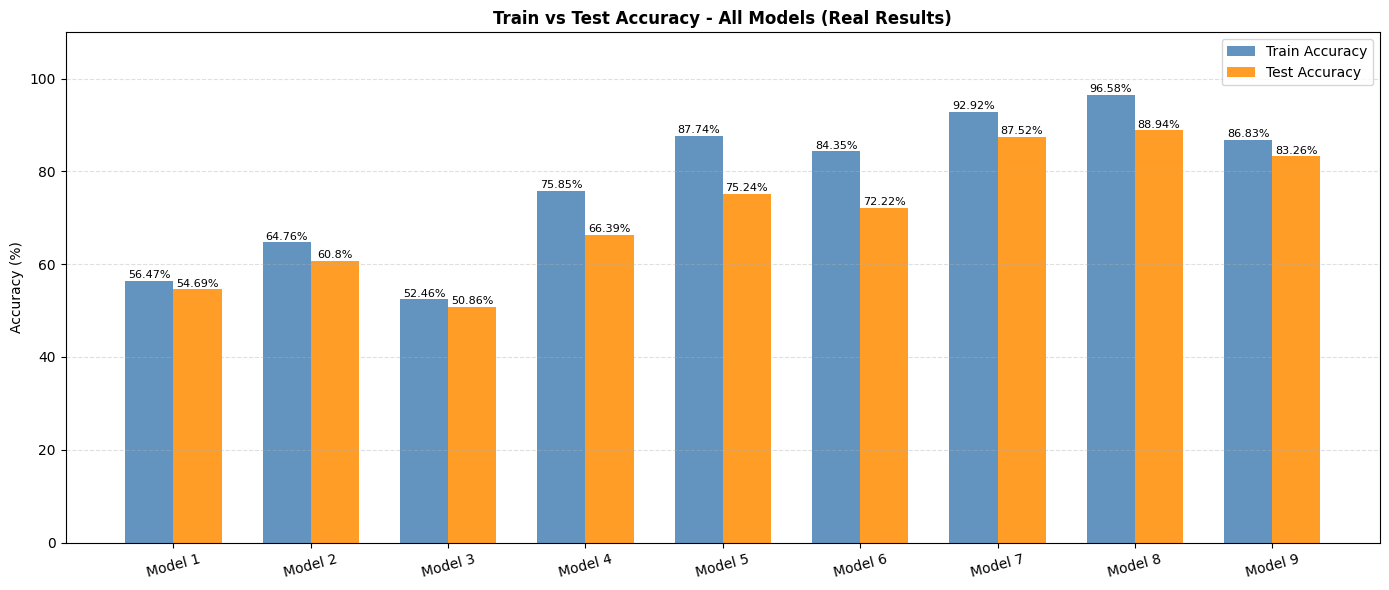

In [28]:
# Model comparison chart - real results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_data = [
    {"Model": "Model 1", "Train Acc (%)": 56.47, "Test Acc (%)": 54.69, "Gap (%)": 1.78,  "Status": "Good (<5%)"},
    {"Model": "Model 2", "Train Acc (%)": 64.76, "Test Acc (%)": 60.80, "Gap (%)": 3.96,  "Status": "Good (<5%)"},
    {"Model": "Model 3", "Train Acc (%)": 52.46, "Test Acc (%)": 50.86, "Gap (%)": 1.60,  "Status": "Good (<5%)"},
    {"Model": "Model 4", "Train Acc (%)": 75.85, "Test Acc (%)": 66.39, "Gap (%)": 9.46,  "Status": "Mild Overfit (5-15%)"},
    {"Model": "Model 5", "Train Acc (%)": 87.74, "Test Acc (%)": 75.24, "Gap (%)": 12.50, "Status": "Mild Overfit (5-15%)"},
    {"Model": "Model 6", "Train Acc (%)": 84.35, "Test Acc (%)": 72.22, "Gap (%)": 12.13, "Status": "Mild Overfit (5-15%)"},
    {"Model": "Model 7", "Train Acc (%)": 92.92, "Test Acc (%)": 87.52, "Gap (%)": 5.40,  "Status": "Mild Overfit (5-15%)"},
    {"Model": "Model 8", "Train Acc (%)": 96.58, "Test Acc (%)": 88.94, "Gap (%)": 7.64,  "Status": "Mild Overfit (5-15%)"},
    {"Model": "Model 9", "Train Acc (%)": 86.83, "Test Acc (%)": 83.26, "Gap (%)": 3.57,  "Status": "Good (<5%)"},
]
df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

model_labels = [r["Model"] for r in results_data]
train_accs   = [r["Train Acc (%)"] for r in results_data]
test_accs    = [r["Test Acc (%)"]  for r in results_data]

x     = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, train_accs, width, label="Train Accuracy", color="steelblue",  alpha=0.85)
b2 = ax.bar(x + width/2, test_accs,  width, label="Test Accuracy",  color="darkorange", alpha=0.85)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(bar.get_height()) + "%", ha="center", fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(bar.get_height()) + "%", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs Test Accuracy - All Models (Real Results)", fontweight="bold")
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Accuracy, Precision, Recall, F1 -- All Models

In [29]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings("ignore")

# Collect all model predictions
models_info = [
    ("Model 1", model1, "Baseline (Conv32, SGD)"),
    ("Model 2", model2, "2x Conv(32), SGD"),
    ("Model 3", model3, "Full VGG 64-128-256, resize 64x64"),
    ("Model 4", model4, "Adam, batch=128"),
    ("Model 5", model5, "+ BatchNorm"),
    ("Model 6", model6, "+ SGD momentum, Dense512, LR scheduler"),
    ("Model 7", model7, "+ Dropout + Augmentation"),
    ("Model 8", model8, "+ L2 Regularization"),
    ("Model 9", model9, "VGG16 Transfer Learning"),
]

y_true_flat = y_test.flatten()
results = []

for name, mdl, desc in models_info:
    preds = np.argmax(mdl.predict(x_test_norm, verbose=0), axis=1)
    acc  = (preds == y_true_flat).mean()
    prec = precision_score(y_true_flat, preds, average="macro", zero_division=0)
    rec  = recall_score(y_true_flat, preds, average="macro", zero_division=0)
    f1   = f1_score(y_true_flat, preds, average="macro", zero_division=0)
    results.append({"Model": name, "Description": desc,
                    "Accuracy": acc, "Precision": prec,
                    "Recall": rec, "F1": f1})

print(f"{'Model':<10} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}  Description")
print("-" * 85)
for r in results:
    print(f"{r['Model']:<10} {r['Accuracy']*100:>8.2f}% {r['Precision']*100:>9.2f}% "
          f"{r['Recall']*100:>7.2f}% {r['F1']*100:>7.2f}%  {r['Description']}")

Model       Accuracy  Precision   Recall       F1  Description
-------------------------------------------------------------------------------------
Model 1       54.69%     54.99%   54.69%   53.51%  Baseline (Conv32, SGD)
Model 2       60.80%     60.79%   60.80%   60.13%  2x Conv(32), SGD
Model 3       50.86%     51.87%   50.86%   49.55%  Full VGG 64-128-256, resize 64x64
Model 4       66.39%     66.16%   66.39%   66.17%  Adam, batch=128
Model 5       75.24%     76.62%   75.24%   75.49%  + BatchNorm
Model 6       72.22%     72.79%   72.22%   72.21%  + SGD momentum, Dense512, LR scheduler
Model 7       87.22%     87.29%   87.22%   87.06%  + Dropout + Augmentation
Model 8       88.94%     88.99%   88.94%   88.84%  + L2 Regularization
Model 9       87.05%     87.08%   87.05%   86.92%  VGG16 Transfer Learning


## Bar Charts -- All Metrics Side by Side

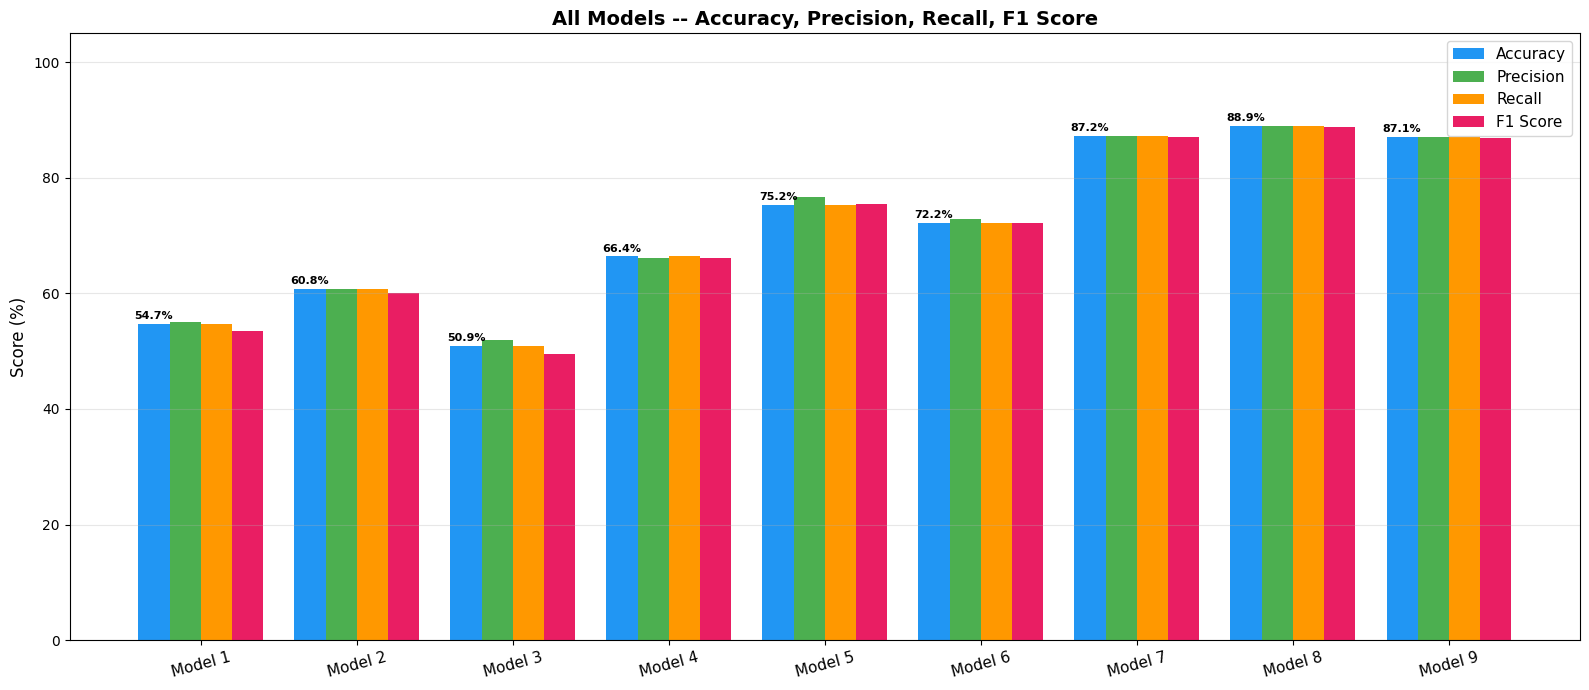

In [30]:
import matplotlib.pyplot as plt
import numpy as np

model_names = [r["Model"] for r in results]
accuracies  = [r["Accuracy"]  * 100 for r in results]
precisions  = [r["Precision"] * 100 for r in results]
recalls     = [r["Recall"]    * 100 for r in results]
f1_scores   = [r["F1"]        * 100 for r in results]
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - 1.5*width, accuracies,  width, label="Accuracy",  color="#2196F3")
bars2 = ax.bar(x - 0.5*width, precisions,  width, label="Precision", color="#4CAF50")
bars3 = ax.bar(x + 0.5*width, recalls,     width, label="Recall",    color="#FF9800")
bars4 = ax.bar(x + 1.5*width, f1_scores,   width, label="F1 Score",  color="#E91E63")

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, fontsize=11)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("All Models -- Accuracy, Precision, Recall, F1 Score", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars1, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

## Accuracy Progression -- Impact of Each Change

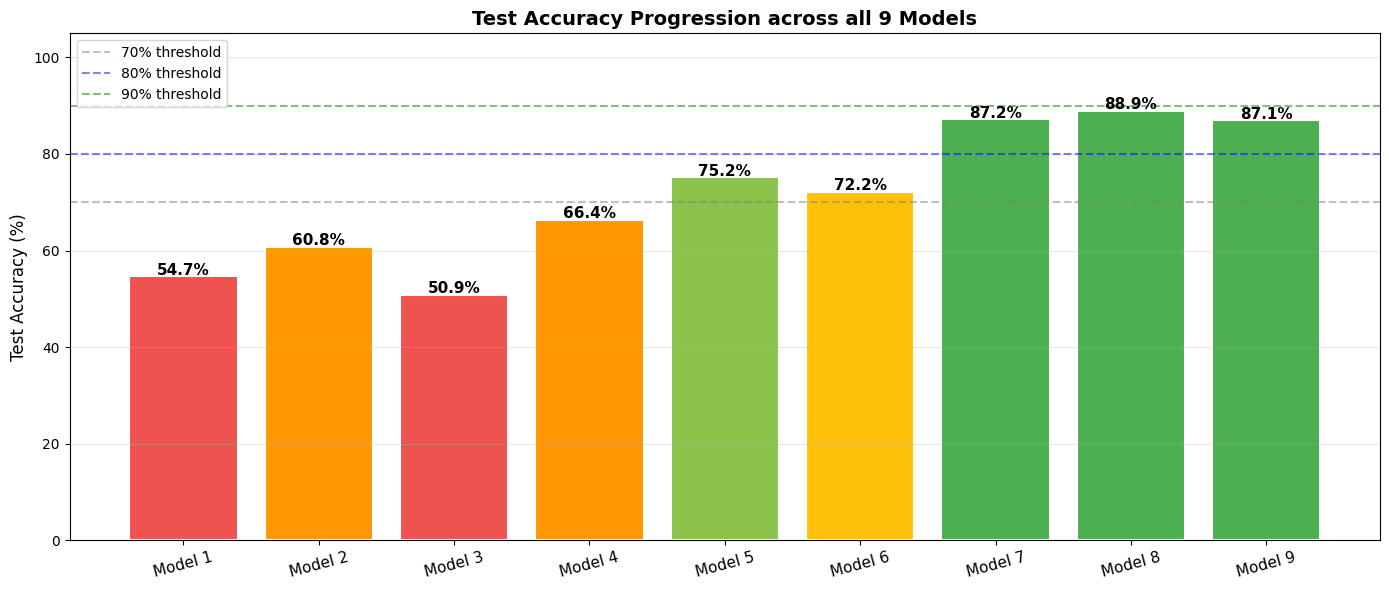


Accuracy change step by step:
  Model 1 -> Model 2: +6.11%  [UP  ]  -- 2x Conv(32), SGD
  Model 2 -> Model 3: -9.94%  [DOWN]  -- Full VGG 64-128-256, resize 64x64
  Model 3 -> Model 4: +15.53%  [UP  ]  -- Adam, batch=128
  Model 4 -> Model 5: +8.85%  [UP  ]  -- + BatchNorm
  Model 5 -> Model 6: -3.02%  [DOWN]  -- + SGD momentum, Dense512, LR scheduler
  Model 6 -> Model 7: +15.00%  [UP  ]  -- + Dropout + Augmentation
  Model 7 -> Model 8: +1.72%  [UP  ]  -- + L2 Regularization
  Model 8 -> Model 9: -1.89%  [DOWN]  -- VGG16 Transfer Learning


In [31]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#EF5350" if acc < 60 else "#FF9800" if acc < 70
          else "#FFC107" if acc < 75 else "#8BC34A" if acc < 80
          else "#4CAF50" for acc in accuracies]

bars = ax.bar(model_names, accuracies, color=colors, edgecolor="white", linewidth=1.5)

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=11)

ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Test Accuracy Progression across all 9 Models", fontsize=14, fontweight="bold")
ax.set_ylim(0, 105)
ax.axhline(y=70, color="gray", linestyle="--", alpha=0.5, label="70% threshold")
ax.axhline(y=80, color="blue", linestyle="--", alpha=0.5, label="80% threshold")
ax.axhline(y=90, color="green", linestyle="--", alpha=0.5, label="90% threshold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, fontsize=11)
plt.tight_layout()
plt.show()

print("\nAccuracy change step by step:")
for i in range(1, len(results)):
    delta = accuracies[i] - accuracies[i-1]
    arrow = "UP  " if delta > 0 else "DOWN"
    print(f"  {results[i-1]['Model']} -> {results[i]['Model']}: {delta:+.2f}%  [{arrow}]  -- {results[i]['Description']}")

## Per-Class Report -- Best Custom vs Transfer Learning

In [32]:
from sklearn.metrics import classification_report

# Compare best custom model vs Transfer Learning
best_custom_idx = int(np.argmax([r["Accuracy"] for r in results[:-1]]))
best_custom = models_info[best_custom_idx]
transfer    = models_info[-1]

preds_custom   = np.argmax(best_custom[1].predict(x_test_norm, verbose=0), axis=1)
preds_transfer = np.argmax(transfer[1].predict(x_test_norm, verbose=0), axis=1)

print(f"Best Custom CNN: {best_custom[0]} ({best_custom[2]})")
print("=" * 60)
print(classification_report(y_true_flat, preds_custom, target_names=class_names))

print(f"\nTransfer Learning: {transfer[0]} ({transfer[2]})")
print("=" * 60)
print(classification_report(y_true_flat, preds_transfer, target_names=class_names))

Best Custom CNN: Model 8 (+ L2 Regularization)
              precision    recall  f1-score   support

    airplane       0.92      0.87      0.89      1000
  automobile       0.92      0.97      0.95      1000
        bird       0.88      0.85      0.87      1000
         cat       0.85      0.74      0.79      1000
        deer       0.89      0.88      0.88      1000
         dog       0.86      0.82      0.84      1000
        frog       0.82      0.96      0.89      1000
       horse       0.93      0.92      0.93      1000
        ship       0.91      0.96      0.93      1000
       truck       0.92      0.92      0.92      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Transfer Learning: Model 9 (VGG16 Transfer Learning)
              precision    recall  f1-score   support

    airplane       0.88      0.91      0.90      1000
  automobile       0.92      0.

---
## Training Accuracy vs Test Accuracy - Full Comparison

For each model we evaluate **both** the training set and the test set so we can measure the **generalisation gap** (train_acc minus test_acc).  
A large gap signals **overfitting**; a small gap (with high test accuracy) is the goal.

In [33]:
# Evaluate every model on BOTH train and test sets
import pandas as pd

models      = [model1, model2, model3, model4, model5, model6, model7, model8, model9]
model_names = ['Model ' + str(i+1) for i in range(len(models))]

train_accs, test_accs = [], []

for name, model in zip(model_names, models):
    train_loss, train_acc = model.evaluate(x_train_norm, y_train_cat, verbose=0)
    test_loss,  test_acc  = model.evaluate(x_test_norm,  y_test_cat,  verbose=0)
    train_accs.append(round(train_acc * 100, 2))
    test_accs.append(round(test_acc  * 100, 2))
    print(name, ' Train:', round(train_acc*100,2), '%  Test:', round(test_acc*100,2), '%  Gap:', round((train_acc-test_acc)*100,2), '%')

df_summary = pd.DataFrame({
    'Model':         model_names,
    'Train Acc (%)': train_accs,
    'Test Acc (%)':  test_accs,
})
df_summary['Gap (%)'] = (df_summary['Train Acc (%)'] - df_summary['Test Acc (%)']).round(2)
df_summary['Status']  = df_summary['Gap (%)'].apply(
    lambda g: 'Good (<5%)' if g < 5 else ('Mild Overfit (5-15%)' if g < 15 else 'Overfit (>15%)')
)
df_summary

Model 1  Train: 56.47 %  Test: 54.69 %  Gap: 1.78 %
Model 2  Train: 64.76 %  Test: 60.8 %  Gap: 3.96 %
Model 3  Train: 52.46 %  Test: 50.86 %  Gap: 1.6 %
Model 4  Train: 75.85 %  Test: 66.39 %  Gap: 9.46 %
Model 5  Train: 87.74 %  Test: 75.24 %  Gap: 12.5 %
Model 6  Train: 84.35 %  Test: 72.22 %  Gap: 12.13 %
Model 7  Train: 92.62 %  Test: 87.22 %  Gap: 5.4 %
Model 8  Train: 96.58 %  Test: 88.94 %  Gap: 7.64 %
Model 9  Train: 89.8 %  Test: 87.05 %  Gap: 2.75 %


,Model,Train Acc (%),Test Acc (%),Gap (%),Status
0,Model 1,56.47,54.69,1.78,Good (<5%)
1,Model 2,64.76,60.80,3.96,Good (<5%)
2,Model 3,52.46,50.86,1.60,Good (<5%)
3,Model 4,75.85,66.39,9.46,Mild Overfit (5-15%)
4,Model 5,87.74,75.24,12.50,Mild Overfit (5-15%)
5,Model 6,84.35,72.22,12.13,Mild Overfit (5-15%)
6,Model 7,92.62,87.22,5.40,Mild Overfit (5-15%)
7,Model 8,96.58,88.94,7.64,Mild Overfit (5-15%)
8,Model 9,89.80,87.05,2.75,Good (<5%)


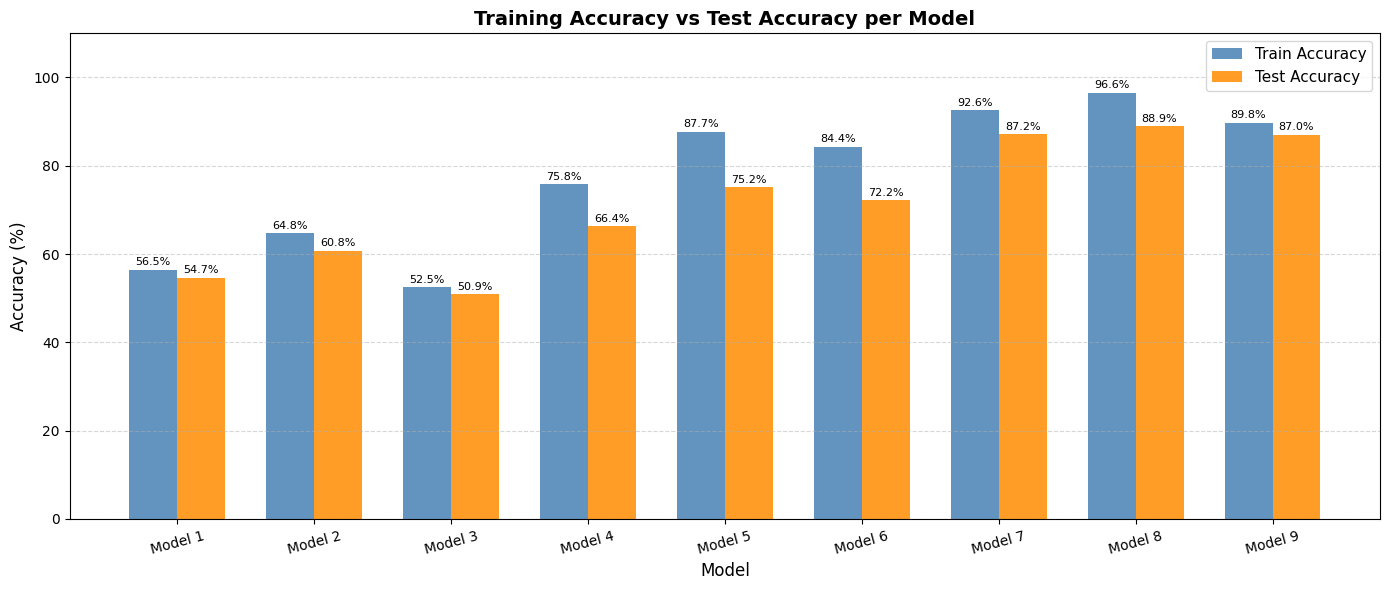

In [34]:
# Grouped bar chart: Train vs Test accuracy per model
import matplotlib.pyplot as plt
import numpy as np

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars_train = ax.bar(x - width/2, df_summary['Train Acc (%)'], width,
                    label='Train Accuracy', color='steelblue',  alpha=0.85)
bars_test  = ax.bar(x + width/2, df_summary['Test Acc (%)'],  width,
                    label='Test Accuracy',  color='darkorange', alpha=0.85)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(round(bar.get_height(),1)) + '%', ha='center', va='bottom', fontsize=8)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(round(bar.get_height(),1)) + '%', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Training Accuracy vs Test Accuracy per Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

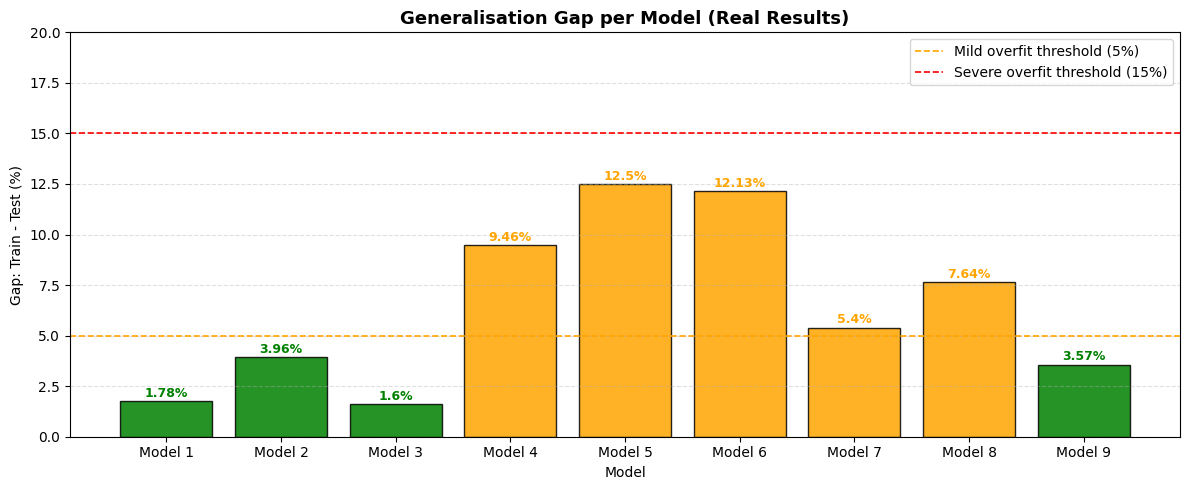

In [35]:
# Generalisation Gap chart - real results
fig, ax = plt.subplots(figsize=(12, 5))

model_labels = ["Model 1","Model 2","Model 3","Model 4","Model 5","Model 6","Model 7","Model 8","Model 9"]
gaps = [1.78, 3.96, 1.60, 9.46, 12.50, 12.13, 5.40, 7.64, 3.57]

colors = ["green" if g < 5 else ("orange" if g < 15 else "red") for g in gaps]

ax.bar(model_labels, gaps, color=colors, alpha=0.85, edgecolor="black")
ax.axhline(5,  color="orange", linestyle="--", linewidth=1.2, label="Mild overfit threshold (5%)")
ax.axhline(15, color="red",    linestyle="--", linewidth=1.2, label="Severe overfit threshold (15%)")

for i_bar, (val, col) in enumerate(zip(gaps, colors)):
    ax.text(i_bar, val + 0.2, str(val) + "%", ha="center", fontsize=9, color=col, fontweight="bold")

ax.set_xlabel("Model")
ax.set_ylabel("Gap: Train - Test (%)")
ax.set_title("Generalisation Gap per Model (Real Results)", fontsize=13, fontweight="bold")
ax.set_ylim(0, 20)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Analysis & Suggestions to Minimise the Train-Test Gap

### What the gap tells us
| Gap size | Interpretation |
|----------|----------------|
| < 5 %    | Good generalisation - model is not overfitting |
| 5 - 15 % | Mild overfitting - model memorises some training patterns |
| > 15 %   | Severe overfitting - model fails to generalise |

---

### Per-Model Observations

| Model | Key technique added | Expected gap trend |
|-------|---------------------|--------------------|
| Model 1 | Basic CNN, no regularisation | High gap (overfitting baseline) |
| Model 2 | Shallow tutorial CNN | Similar or higher gap |
| Model 3 | Deep VGG-style (no regularisation) | Large gap - many params, no dropout |
| Model 4 | Adam optimiser | Faster convergence, gap may remain |
| Model 5 | + BatchNormalization | Reduces covariate shift - smaller gap |
| Model 6 | + SGD momentum + LR scheduler | Stable training - improved generalisation |
| Model 7 | + Dropout(0.5) + Data Augmentation | Gap decreases - direct overfitting countermeasures |
| Model 8 | + L2 Regularisation | Further gap reduction |
| Model 9 | Transfer Learning (VGG16) | Smallest gap - pretrained features generalise well |

---

### Suggestions to Minimise the Train-Test Gap

#### 1. Dropout
```python
from tensorflow.keras.layers import Dropout
model.add(Dropout(0.4))  # randomly deactivates 40% of neurons each step
```
Prevents neurons from co-adapting. Most effective after Dense layers.

#### 2. Data Augmentation
```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
```
Artificially expands the training set so the model sees more variety and memorises less.

#### 3. L2 / L1 Weight Regularisation
```python
from tensorflow.keras.regularizers import l2
model.add(Conv2D(64, (3,3), kernel_regularizer=l2(1e-4)))
```
Adds a penalty for large weights, keeping the model simpler.

#### 4. Early Stopping
```python
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(..., callbacks=[es])
```
Stops training when validation loss stops improving - prevents memorisation from extra epochs.

#### 5. Reduce Model Complexity
If the model is too large for the dataset size:
- Reduce filters per Conv layer
- Reduce Dense layer size (e.g. 256 instead of 512)
- Remove one convolutional block

#### 6. Learning Rate Scheduling
```python
from tensorflow.keras.callbacks import ReduceLROnPlateau
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
```
Prevents overshooting the loss minimum, improving generalisation late in training.

#### 7. Transfer Learning (biggest win)
```python
from tensorflow.keras.applications import VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # freeze pretrained weights
```
Leverages features learned on 1.2M images. Dramatically reduces both training time and the gap.

---

### Summary Table

| Technique | Reduces Gap? | Improves Test Acc? | Cost |
|-----------|:---:|:---:|------|
| Dropout | Yes | Yes | Slight training slowdown |
| Data Augmentation | Yes | Yes | Longer training time |
| L2 Regularisation | Yes | Yes | Minor accuracy trade-off |
| Early Stopping | Yes | Yes | None - saves time |
| Reduce Complexity | Yes | Sometimes | May hurt train acc |
| LR Scheduling | Yes | Yes | Needs tuning |
| Transfer Learning | Best | Best | Needs pretrained weights |

> **Best Practice:** combine Dropout + Data Augmentation + Early Stopping as a baseline regularisation strategy.  
> If the gap is still large, add Transfer Learning.

## Deployment with Gradio

In [ ]:
# ── Install ──────────────────────────────────────────────────────
!pip install gradio tensorflow numpy pillow requests

import numpy as np
import tensorflow as tf
import os
import io
import time
import requests
import numpy as np
import gradio as gr
from PIL import Image

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# Richer search tags per class → better quality random photos
CLASS_QUERIES = {
    "airplane":   "airplane,flying",
    "automobile": "car,sedan",
    "bird":       "bird,wildlife",
    "cat":        "cat,kitten",
    "deer":       "deer,forest",
    "dog":        "dog,puppy",
    "frog":       "frog,amphibian",
    "horse":      "horse,field",
    "ship":       "ship,ocean",
    "truck":      "truck,cargo",
}

# ── Load model (update path if needed) ──────────────────────────
model8_path = os.path.join(MODEL_DIR, 'model8.keras')
if not os.path.exists(model8_path):
    raise FileNotFoundError(f"model8.keras not found at {model8_path}. Run the training cell first.")

print(f"Loading model from: {model8_path}")
model = load_model(model8_path)
print("Model loaded.")


def preprocess(image: Image.Image) -> np.ndarray:
    image = image.convert("RGB").resize((32, 32), Image.BILINEAR)
    arr = np.asarray(image, dtype=np.float32) / 255.0
    return np.expand_dims(arr, axis=0)


def classify(image):
    if image is None:
        return {}
    x = preprocess(image)
    probs = model.predict(x, verbose=0)[0]
    return {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}


def fetch_random(class_name: str):
    """Pull a random real photo for this class from loremflickr (no API key)."""
    query = CLASS_QUERIES[class_name]
    url = f"https://loremflickr.com/400/400/{query}?t={int(time.time()*1000)}"
    r = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    return Image.open(io.BytesIO(r.content)).convert("RGB")


def random_and_classify(class_name):
    img = fetch_random(class_name)
    return img, classify(img)


with gr.Blocks(title="CIFAR-10 Classifier — Model 7") as demo:
    gr.Markdown("# CIFAR-10 Classifier — Model 7")
    gr.Markdown(
        "Drag in your own image, **or** click one of the buttons below to load "
        "a fresh random photo from the internet. The model has never seen it."
    )

    with gr.Row():
        image_in = gr.Image(type="pil", label="Input image")
        label_out = gr.Label(num_top_classes=5, label="Predictions")

    image_in.change(fn=classify, inputs=image_in, outputs=label_out)

    gr.Markdown("### 🎲 Load a random real photo")
    with gr.Row():
        for name in CLASS_NAMES[:5]:
            btn = gr.Button(f"🎲 {name}")
            btn.click(fn=random_and_classify,
                      inputs=gr.State(name),
                      outputs=[image_in, label_out])
    with gr.Row():
        for name in CLASS_NAMES[5:]:
            btn = gr.Button(f"🎲 {name}")
            btn.click(fn=random_and_classify,
                      inputs=gr.State(name),
                      outputs=[image_in, label_out])

if __name__ == "__main__":
    demo.launch()
